In [1]:
import numpy as np
import pandas as pd
import seaborn as sns

from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense
import tensorflow as tf

import matplotlib.pyplot as plt

In [3]:
from google.colab import files
uploaded = files.upload()

Saving data.csv to data.csv


In [ ]:
df = pd.read_csv('data.csv')
df.head()

,Month,Vietnam Exporting Volume ( Thousand tons),Vietnam Rice export Value (Mill. USD),Exchange Rate (thousand VND/Dollar),Hour of Sunlight (Hour),Average Temperature (Celcius),Average Moisture ( ),Average Rainfall (mm),Thailand (Value),Thailand (Volume)
0,08/2008,450.0,392.0,15970.0,171.20,27.080000,83.066667,247.000000,594101.0,384.0
1,09/2008,400.0,232.0,15930.5,144.87,26.513333,84.133333,302.600000,550581.0,334.0
2,10/2008,350.0,230.0,16110.0,131.80,25.426667,85.533333,426.933333,403337.0,234.0
3,11/2008,250.0,119.0,16122.0,122.20,22.366667,82.933333,284.933333,287261.0,147.0
4,12/2008,350.0,147.0,16246.0,116.67,20.053333,81.666667,114.866667,365450.0,180.0


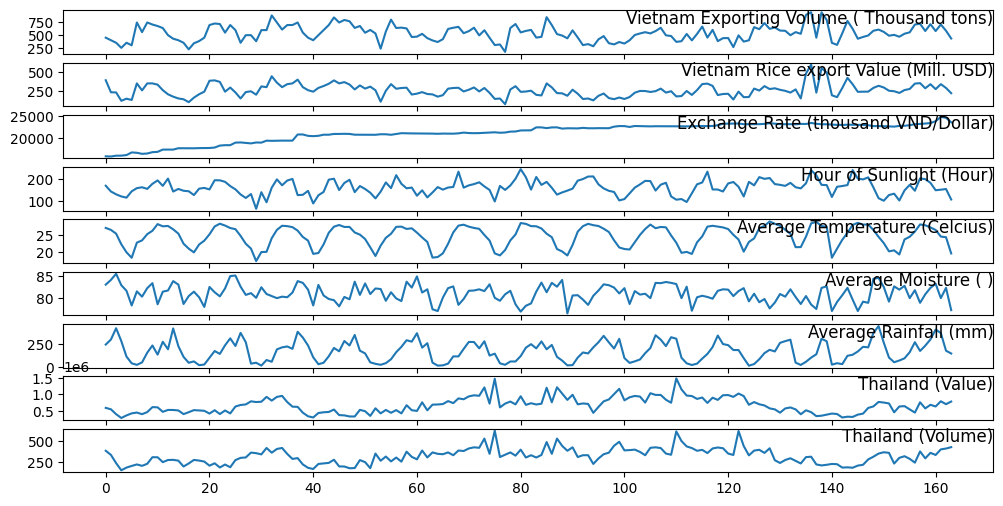

In [ ]:
values = df.values
# specify columns to plot
groups = [1, 2, 3, 4, 5, 6, 7, 8, 9]
i = 1
# plot each column
plt.figure(figsize=(12, 6))
for group in groups:
 plt.subplot(len(groups), 1, i)
 plt.plot(values[:, group])
 plt.title(df.columns[group], y=0.5, loc='right')
 i += 1
plt.show()

<ipython-input-5-c067bc0b2825>:1: FutureWarning: The default value of numeric_only in DataFrame.corr is deprecated. In a future version, it will default to False. Select only valid columns or specify the value of numeric_only to silence this warning.
  sns.heatmap(df.corr(),annot=True, cbar=False, cmap='Blues', fmt='.1f')


<Axes: >

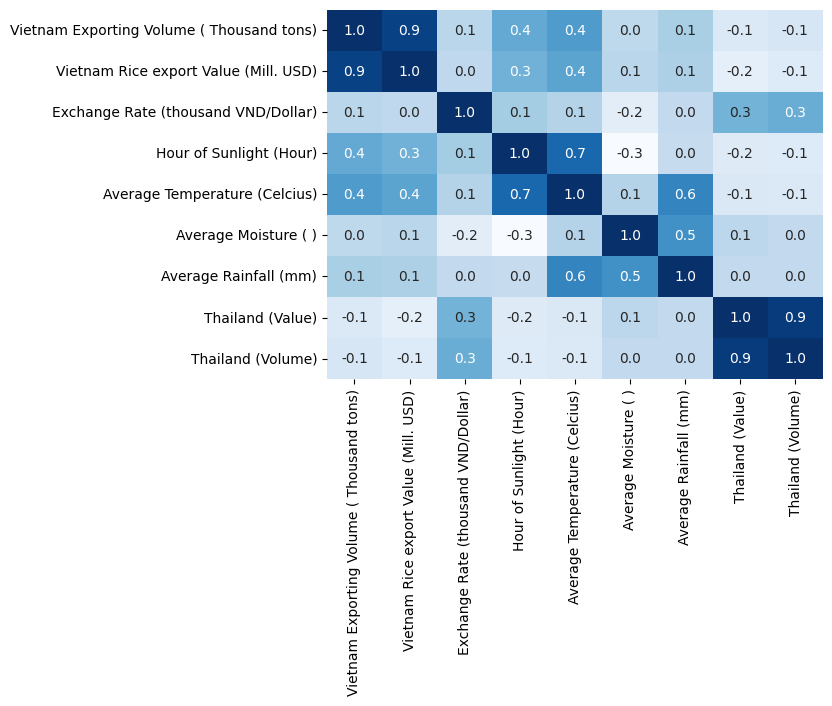

In [ ]:
sns.heatmap(df.corr(),annot=True, cbar=False, cmap='Blues', fmt='.1f')

In [ ]:
features = df.drop(['Vietnam Exporting Volume ( Thousand tons)'], axis = 1)
target = df['Vietnam Exporting Volume ( Thousand tons)']

In [ ]:
features

,Month,Vietnam Rice export Value (Mill. USD),Exchange Rate (thousand VND/Dollar),Hour of Sunlight (Hour),Average Temperature (Celcius),Average Moisture ( ),Average Rainfall (mm),Thailand (Value),Thailand (Volume)
0,08/2008,392.000000,15970.0,171.20,27.080000,83.066667,247.000000,594101.0,384.0
1,09/2008,232.000000,15930.5,144.87,26.513333,84.133333,302.600000,550581.0,334.0
2,10/2008,230.000000,16110.0,131.80,25.426667,85.533333,426.933333,403337.0,234.0
3,11/2008,119.000000,16122.0,122.20,22.366667,82.933333,284.933333,287261.0,147.0
4,12/2008,147.000000,16246.0,116.67,20.053333,81.666667,114.866667,365450.0,180.0
...,...,...,...,...,...,...,...,...,...
159,08/2022,339.259336,23450.0,184.36,27.226667,82.333333,303.686667,687118.0,359.0
160,09/2022,273.747566,23855.0,150.55,26.493333,83.266667,412.233333,636731.0,333.0
161,10/2022,339.842876,24840.0,153.03,24.586667,80.000000,373.926667,794224.0,401.0
162,11/2022,289.417181,24630.0,156.14,24.400000,82.333333,179.473333,706270.0,411.0


In [ ]:
# Convert 'month' column to datetime
features['Month'] = pd.to_datetime(features['Month'], format='%m/%Y')
features['Year'] = features['Month'].dt.year
features['Month'] = features['Month'].dt.month

In [ ]:
features

,Month,Vietnam Rice export Value (Mill. USD),Exchange Rate (thousand VND/Dollar),Hour of Sunlight (Hour),Average Temperature (Celcius),Average Moisture ( ),Average Rainfall (mm),Thailand (Value),Thailand (Volume),Year
0,8,392.000000,15970.0,171.20,27.080000,83.066667,247.000000,594101.0,384.0,2008
1,9,232.000000,15930.5,144.87,26.513333,84.133333,302.600000,550581.0,334.0,2008
2,10,230.000000,16110.0,131.80,25.426667,85.533333,426.933333,403337.0,234.0,2008
3,11,119.000000,16122.0,122.20,22.366667,82.933333,284.933333,287261.0,147.0,2008
4,12,147.000000,16246.0,116.67,20.053333,81.666667,114.866667,365450.0,180.0,2008
...,...,...,...,...,...,...,...,...,...,...
159,8,339.259336,23450.0,184.36,27.226667,82.333333,303.686667,687118.0,359.0,2022
160,9,273.747566,23855.0,150.55,26.493333,83.266667,412.233333,636731.0,333.0,2022
161,10,339.842876,24840.0,153.03,24.586667,80.000000,373.926667,794224.0,401.0,2022
162,11,289.417181,24630.0,156.14,24.400000,82.333333,179.473333,706270.0,411.0,2022


In [ ]:
features_scaler = MinMaxScaler()
target_scaler = MinMaxScaler()
# Normalize the non-month features using Min-Max scaling
features_scaled = features_scaler.fit_transform(features)

# Normalize the target variable separately
target_scaled = target_scaler.fit_transform(target.values.reshape(-1, 1))

In [ ]:
# Create sequences for LSTM
def create_X(data, time_steps=1):
    X = []
    for i in range(len(data) - time_steps):
        X.append(data[i:(i + time_steps), :])
    return np.array(X)

def create_Y(data, time_steps=1):
    y = []
    for i in range(len(data) - time_steps):
        y.append(data[i + time_steps])  # Assuming 'target' is the first column
    return np.array(y)

In [ ]:
time_steps = 1  # Adjust as needed
X = create_X(features_scaled, time_steps)
y = create_Y(target_scaled, time_steps)

In [ ]:
# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [ ]:
model = Sequential()
model.add(LSTM(units=50, activation='relu', input_shape=(X_train.shape[1], X_train.shape[2])))
model.add(Dense(units=1))  # Output layer with 1 neuron for regression

learning_rate = 0.001
optimizer = tf.keras.optimizers.Adam(learning_rate=learning_rate)

model.compile(optimizer=optimizer, loss='mean_squared_error')

In [ ]:
#train model
model.fit(X_train, y_train, epochs=2000, batch_size=32, validation_data=(X_test, y_test))

Epoch 1/2000
5/5 [==============================] - 2s 72ms/step - loss: 0.2468 - val_loss: 0.2637
Epoch 2/2000
5/5 [==============================] - 0s 15ms/step - loss: 0.2059 - val_loss: 0.2237
Epoch 3/2000
5/5 [==============================] - 0s 12ms/step - loss: 0.1689 - val_loss: 0.1874
Epoch 4/2000
5/5 [==============================] - 0s 14ms/step - loss: 0.1358 - val_loss: 0.1544
Epoch 5/2000
5/5 [==============================] - 0s 10ms/step - loss: 0.1077 - val_loss: 0.1265
Epoch 6/2000
5/5 [==============================] - 0s 14ms/step - loss: 0.0851 - val_loss: 0.1039
Epoch 7/2000
5/5 [==============================] - 0s 10ms/step - loss: 0.0689 - val_loss: 0.0876
Epoch 8/2000
5/5 [==============================] - 0s 14ms/step - loss: 0.0577 - val_loss: 0.0761
Epoch 9/2000
5/5 [==============================] - 0s 15ms/step - loss: 0.0523 - val_loss: 0.0689
Epoch 10/2000
5/5 [==============================] - 0s 15ms/step - loss: 0.0508 - val_loss: 0.0661
Epoch 11/

In [ ]:
loss = model.evaluate(X_test, y_test)
print(f'Test Loss: {loss}')

2/2 [==============================] - 0s 7ms/step - loss: 0.0542
Test Loss: 0.05424807220697403


In [ ]:
#predict the test data
pred = model.predict(X_test)

2/2 [==============================] - 0s 5ms/step


In [ ]:
pred_Inverse = target_scaler.inverse_transform(pred) #pred from model
pred_Inverse.shape

(33, 1)

In [ ]:
# Inverse transform the y_test for plotting
y_test_actual = target_scaler.inverse_transform(y_test.reshape(-1, 1))

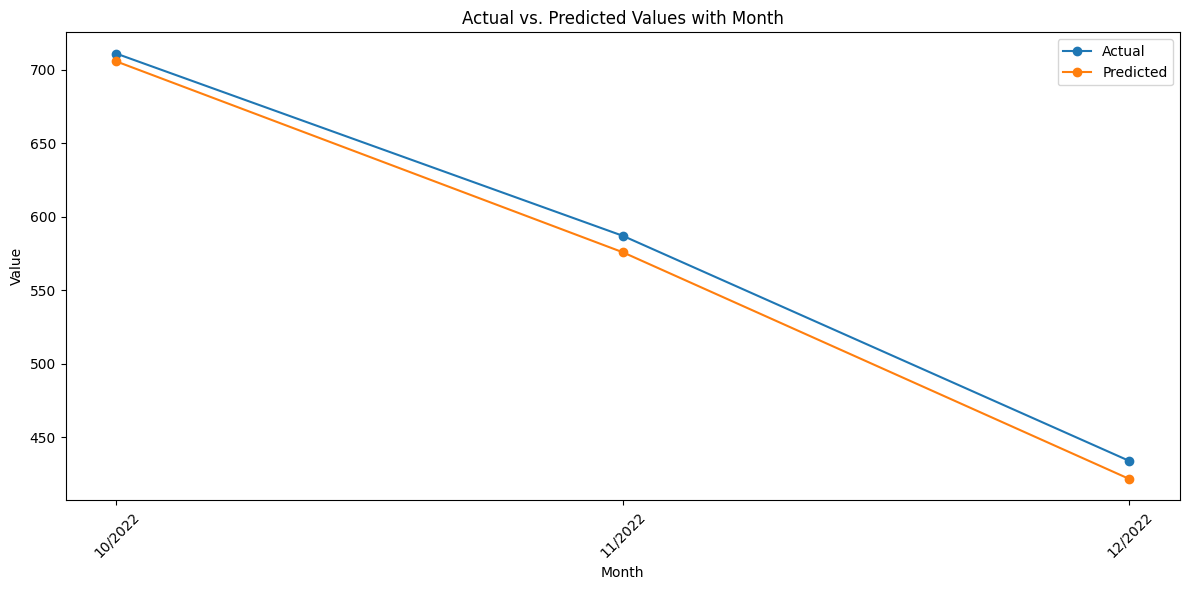

In [ ]:
last_3_months = df.tail(3)

plt.figure(figsize=(12, 6))
plt.plot(last_3_months['Month'], target[-3:], label='Actual', marker='o')
plt.plot(last_3_months['Month'], pred_Inverse[-3:], label='Predicted', marker='o')
plt.title('Actual vs. Predicted Values with Month')
plt.xlabel('Month')
plt.ylabel('Value')
plt.legend()
plt.xticks(rotation=45)  # Rotate x-axis labels for better readability
plt.tight_layout()
plt.show()

In [ ]:
from sklearn import metrics

actual_value = target[161:]
pred3m = pred_Inverse[-3:]

def timeseries_evaluation_metrics_func(y_true, y_pred):
    def mean_absolute_percentage_error(y_true, y_pred):
      y_true, y_pred = np.array(y_true), np.array(y_pred)
      return np.mean(np.abs((y_true - y_pred) / y_true)) * 100
    print('Evaluation metric results:-')
    print(f'RMSE is : {np.sqrt(metrics.mean_squared_error(y_true, y_pred))}')
    print(f'MSE is : {metrics.mean_squared_error(y_true, y_pred)}')
    print(f'MAE is : {metrics.mean_absolute_error(y_true, y_pred)}')

timeseries_evaluation_metrics_func(actual_value, pred3m )

Evaluation metric results:-
RMSE is : 10.068143419085509
MSE is : 101.36751190727482
MAE is : 9.593626057942686
